In [2]:
%pip install sympy

   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   -------------------------------------- - 6.0/6.3 MB 36.1 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 30.2 MB/s  0:00:00
   ---------------------------------------- 0.0/536.2 kB ? eta -:--:--
   ---------------------------------------- 536.2/536.2 kB 12.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   -------------------- ------------------- 1/2 [sympy]
   -------------------- ------------------- 1/2 [sympy]
   -------------------- ------------------- 1/2 [sympy]
   -------------------- ------------------- 1/2 [sympy]
   -------------------- ------------------- 1/2 [sympy]
   -------------------- ------------------- 1/2 [sympy]
   -------------------- ------------------- 1/2 [sympy]
   -------

# Derivatives

In [22]:
import sympy as sp
x, y = sp.symbols('x y')
f = x**2 + 2*y**2 - 4*x - 6*y + x*y + 100

partial_x = f.diff(x)
partial_y = f.diff(y)

print(partial_x)
print(partial_y)

2*x + y - 4
x + 4*y - 6


In [7]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definisikan variabel dan fungsi
x, y = sp.symbols('x y')
f = x**2 + 2*y**2 - 4*x - 6*y + x*y + 100

# Turunan parsial
partial_x = f.diff(x)
partial_y = f.diff(y)

print("∂f/∂x =", partial_x)
print("∂f/∂y =", partial_y)

# 1. Cari titik kritis
critical_points = sp.solve([partial_x, partial_y], (x, y))
print("Titik kritis:", critical_points)

# 2. Substitusi titik kritis ke fungsi biaya
min_cost = f.subs(critical_points)
crit_x, crit_y = float(critical_points[x]), float(critical_points[y])
min_cost_val = float(min_cost)

print(f"Minimum pada x={crit_x:.2f}, y={crit_y:.2f}, cost={min_cost_val:.2f}")


∂f/∂x = 2*x + y - 4
∂f/∂y = x + 4*y - 6
Titik kritis: {x: 10/7, y: 8/7}
Minimum pada x=1.43, y=1.14, cost=93.71


# Cek kurva dengan Matriks Hessian

In [33]:
# 2. Buat matriks Hessian (turunan parsial kedua)
f_xx = f.diff(x, x)
f_xy = f.diff(x, y)
f_yx = f.diff(y, x)
f_yy = f.diff(y, y)

hessian = sp.Matrix([[f_xx, f_xy],
                     [f_yx, f_yy]])


# 3. Evaluasi Hessian di titik kritis
hessian_at_crit = hessian.subs({x: crit_x, y: crit_y})
print("Hessian di titik kritis:")
sp.pprint(hessian_at_crit)

# 4. Tentukan sifat titik kritis menggunakan determinan
det_hessian = hessian_at_crit.det()
trace_hessian = hessian_at_crit.trace()

print(f"Determinant Hessian = {det_hessian}")
print(f"Trace Hessian = {trace_hessian}")

# Analisis:
if det_hessian > 0 and trace_hessian > 0:
    print("Fungsi memiliki minimum lokal di titik kritis (curva terbuka ke atas)")
elif det_hessian > 0 and trace_hessian < 0:
    print("Fungsi memiliki maksimum lokal di titik kritis.")
elif det_hessian < 0:
    print("Titik kritis adalah saddle point.")
else:
    print("Analisis Hessian tidak cukup, titik kritis bisa bersifat degenerate.")

Hessian di titik kritis:
⎡2  1⎤
⎢    ⎥
⎣1  4⎦
Determinant Hessian = 7
Trace Hessian = 6
Fungsi memiliki minimum lokal di titik kritis (curva terbuka ke atas)


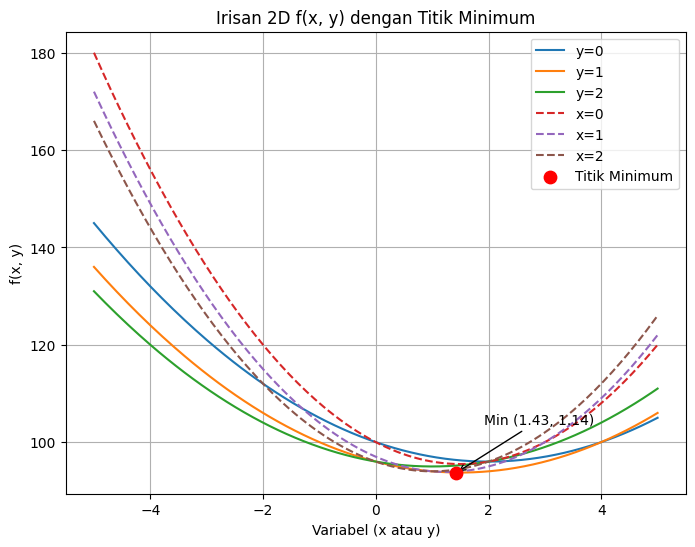

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# --- Definisi simbolik ---
x, y = sp.symbols('x y')
f = x**2 + 2*y**2 - 4*x - 6*y + x*y + 100

# Turunan parsial
partial_x = f.diff(x)
partial_y = f.diff(y)

# Cari titik kritis (minimum)
sol = sp.solve([partial_x, partial_y], (x, y))
x_min = float(sol[x])
y_min = float(sol[y])
f_min = float(f.subs({x: x_min, y: y_min}))

# Konversi ke fungsi numerik
f_func = sp.lambdify((x, y), f, "numpy")

# --- Grid iris 2D ---
x_vals = np.linspace(-5, 5, 200)
y_vals = np.linspace(-5, 5, 200)

# Irisan untuk beberapa nilai y tetap
y_fixed = [0, 1, 2]
# Irisan untuk beberapa nilai x tetap
x_fixed = [0, 1, 2]

plt.figure(figsize=(8, 6))

# Plot f vs x untuk beberapa y tetap
for y0 in y_fixed:
    plt.plot(x_vals, f_func(x_vals, y0), label=f'y={y0}')

# Plot f vs y untuk beberapa x tetap
for x0 in x_fixed:
    plt.plot(y_vals, f_func(x0, y_vals), '--', label=f'x={x0}')  # garis putus-putus

# Tandai titik minimum
plt.scatter(x_min, f_func(x_min, y_min), color='red', s=80, zorder=5, label='Titik Minimum')
plt.annotate(f'Min ({x_min:.2f}, {y_min:.2f})', 
             xy=(x_min, f_func(x_min, y_min)), 
             xytext=(x_min+0.5, f_func(x_min, y_min)+10),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.title('Irisan 2D f(x, y) dengan Titik Minimum')
plt.xlabel('Variabel (x atau y)')
plt.ylabel('f(x, y)')
plt.grid(True)
plt.legend()
plt.show()


In [12]:
# Evaluasi nilai minimum di titik kritis
min_cost = C.subs(critical_points)

# Konversi ke float
crit_x, crit_y = float(critical_points[x]), float(critical_points[y])
min_cost_val = float(min_cost)

crit_x, crit_y, min_cost_val


(1.4285714285714286, 1.1428571428571428, 93.71428571428571)

Critical point (x*, y*): {x: 10/7, y: 8/7}
Minimal cost: 93.71428571428571


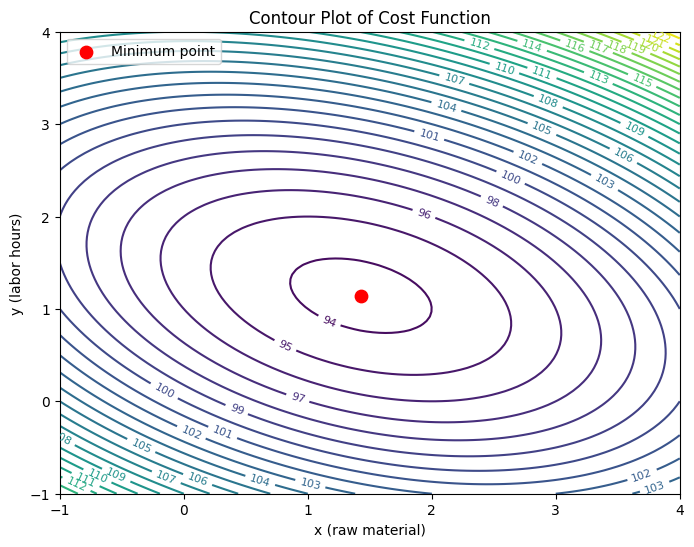

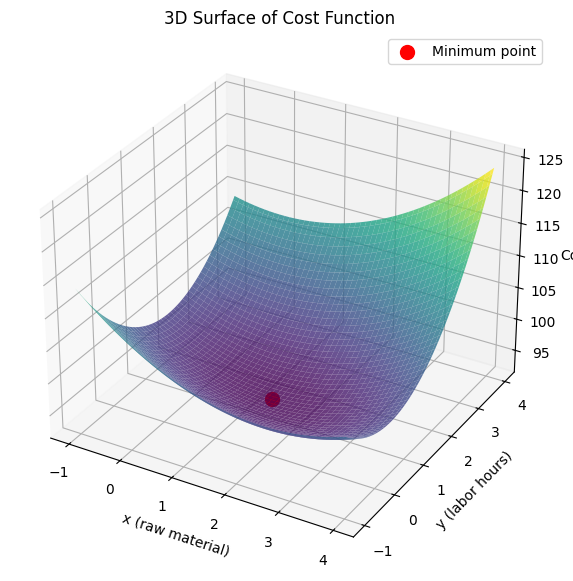

In [5]:
# Minimize Cost Function C(x,y)

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. Define variables and function ---
x, y = sp.symbols('x y')
C = x**2 + 2*y**2 - 4*x - 6*y + x*y + 100

# --- 2. Partial derivatives ---
partial_x = sp.diff(C, x)
partial_y = sp.diff(C, y)

# --- 3. Solve critical point ---
critical_point = sp.solve([partial_x, partial_y], (x, y))
critical_point

# --- 4. Evaluate minimal cost ---
C_min = C.subs(critical_point)

print("Critical point (x*, y*):", critical_point)
print("Minimal cost:", float(C_min))

# --- 5. Visualization ---
X_vals = np.linspace(-1, 4, 100)
Y_vals = np.linspace(-1, 4, 100)
X, Y = np.meshgrid(X_vals, Y_vals)

# lambdify Sympy -> Numpy function
C_func = sp.lambdify((x, y), C, "numpy")
Z = C_func(X, Y)

# --- Contour plot ---
plt.figure(figsize=(8,6))
contours = plt.contour(X, Y, Z, levels=30, cmap="viridis")
plt.clabel(contours, inline=True, fontsize=8)
plt.scatter(float(critical_point[x]), float(critical_point[y]), color="red", s=80, label="Minimum point")
plt.xlabel("x (raw material)")
plt.ylabel("y (labor hours)")
plt.title("Contour Plot of Cost Function")
plt.legend()
plt.show()

# --- 3D Surface plot ---
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.8)
ax.scatter(float(critical_point[x]), float(critical_point[y]), float(C_min), color="red", s=100, label="Minimum point")
ax.set_xlabel("x (raw material)")
ax.set_ylabel("y (labor hours)")
ax.set_zlabel("Cost")
ax.set_title("3D Surface of Cost Function")
ax.legend()
plt.show()


# Integral

In [26]:
import sympy as sp

# Definisikan variabel simbolik
t = sp.symbols('t')

# Fungsi penjualan per jam
sales = 5 + 2*t

# Hitung integral dari jam 0 sampai 4
total_sales = sp.integrate(sales, (t, 0, 4))

print("Total Penjualan 4 jam pertama:", total_sales)


Total Penjualan 4 jam pertama: 36


In [6]:
import numpy as np
from scipy.integrate import quad

# Definisikan fungsi penjualan per jam
def sales(t):
    return 5 + 2*t

# Hitung integral dari jam 0 sampai 4
total_sales, _ = quad(sales, 0, 4)
print("Total Penjualan 4 jam pertama:", total_sales)


Total Penjualan 4 jam pertama: 36.0


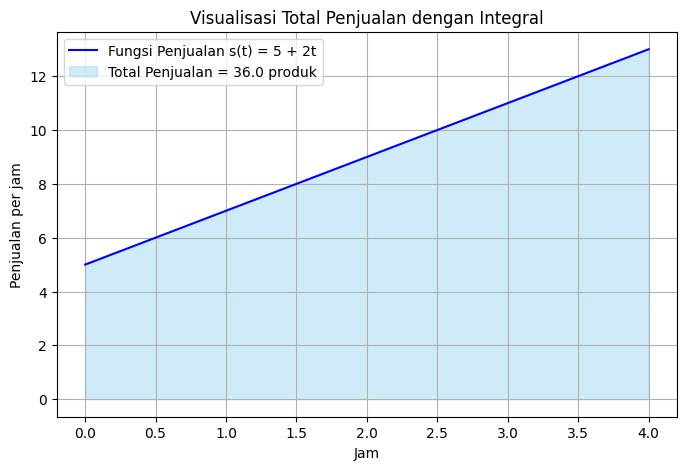

In [4]:
import matplotlib.pyplot as plt


# Buat plot
plt.figure(figsize=(8,5))
plt.plot(t, s, label='Fungsi Penjualan s(t) = 5 + 2t', color='blue')
plt.fill_between(t, s, color='skyblue', alpha=0.4, label=f'Total Penjualan = {total_sales:.1f} produk')
plt.title('Visualisasi Total Penjualan dengan Integral')
plt.xlabel('Jam')
plt.ylabel('Penjualan per jam')
plt.legend()
plt.grid(True)
plt.show()


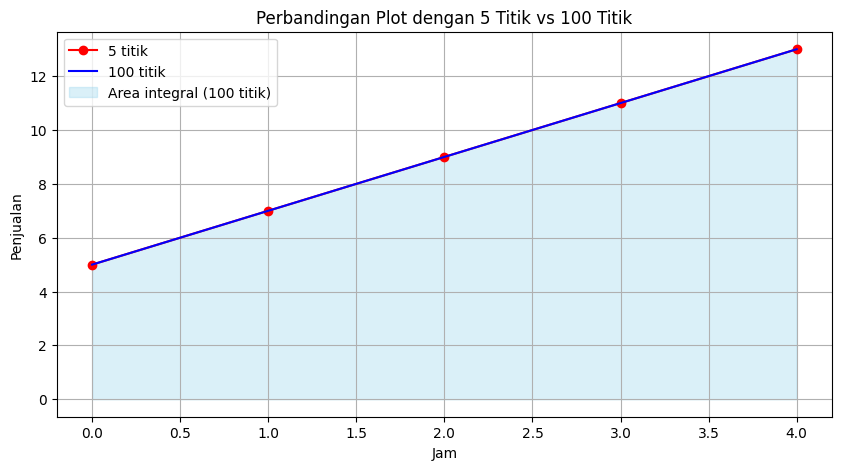

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Fungsi penjualan
def sales(t):
    return 5 + 2*t

# --- 5 Titik ---
t_5 = np.linspace(0, 4, 5)
sales_5 = sales(t_5)

# --- 100 Titik ---
t_100 = np.linspace(0, 4, 100)
sales_100 = sales(t_100)

plt.figure(figsize=(10,5))

# Plot 5 titik
plt.plot(t_5, sales_5, 'o-', label='5 titik', color='red')

# Plot 100 titik
plt.plot(t_100, sales_100, '-', label='100 titik', color='blue')

plt.fill_between(t_100, sales_100, color='skyblue', alpha=0.3, label='Area integral (100 titik)')

plt.title("Perbandingan Plot dengan 5 Titik vs 100 Titik")
plt.xlabel("Jam")
plt.ylabel("Penjualan")
plt.legend()
plt.grid(True)
plt.show()
